# Phase 6 -- Hero Figure for the Decision Memo

* Purpose: produce a single PNG that summarizes the entire experiment for a leadership review. Three panels on one canvas:
    * Top:    Headline KPI -- the +12% conversion win in stakeholder language.
    * Middle: Forest plot of all primary, sensitivity, and segment effects.
    * Bottom: Guardrails snapshot + ship recommendation banner.

* Goal: The Project Manager should be able to look at this image alone and understand the recommendation in < 30 seconds.

In [1]:
import sys
from pathlib import Path

project_root=Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from src.data.loader import load_experiment
from src.analysis.frequentist import two_proportion_test, welch_t_test
from src.analysis.segmentation import segment_lifts

FIG_DIR = project_root / "reports/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_experiment("../data/experiment.csv").dropna(subset=["group", "converted"])
ctl = df[df["group"] == "control"]
trt = df[df["group"] == "treatment"]

# Assemble the numbers

In [3]:
# Primary analysis (ITT)
primary = two_proportion_test(
    int(ctl["converted"].sum()), len(ctl),
    int(trt["converted"].sum()), len(trt),
    name="Conversion (ITT)",
)

# Sensitivity (excl Android)
df_excl = df[df["device"] != "Android"]
ctl_e = df_excl[df_excl["group"] == "control"]
trt_e = df_excl[df_excl["group"] == "treatment"]
sensitivity = two_proportion_test(
    int(ctl_e["converted"].sum()), len(ctl_e),
    int(trt_e["converted"].sum()), len(trt_e),
    name="Excl Android",
)

# Top device segments
device_seg = segment_lifts(df, segment_col="device", metric_col="converted")

# Guardrails
guard_load = welch_t_test(
    ctl["page_load_ms"].values, trt["page_load_ms"].values,
    name="page load (ms)",
)
guard_d7 = two_proportion_test(
    int(ctl["day7_active"].sum()), len(ctl),
    int(trt["day7_active"].sum()), len(trt),
    name="Day-7 active",
)


# Build the Hero Figure

📊 Saved hero figure -> c:\Users\ruthr\OneDrive\Documents\Claude\Projects\Github DS Portfolio Projects\01-ab-test-analysis\reports\figures/06_hero_summary.png


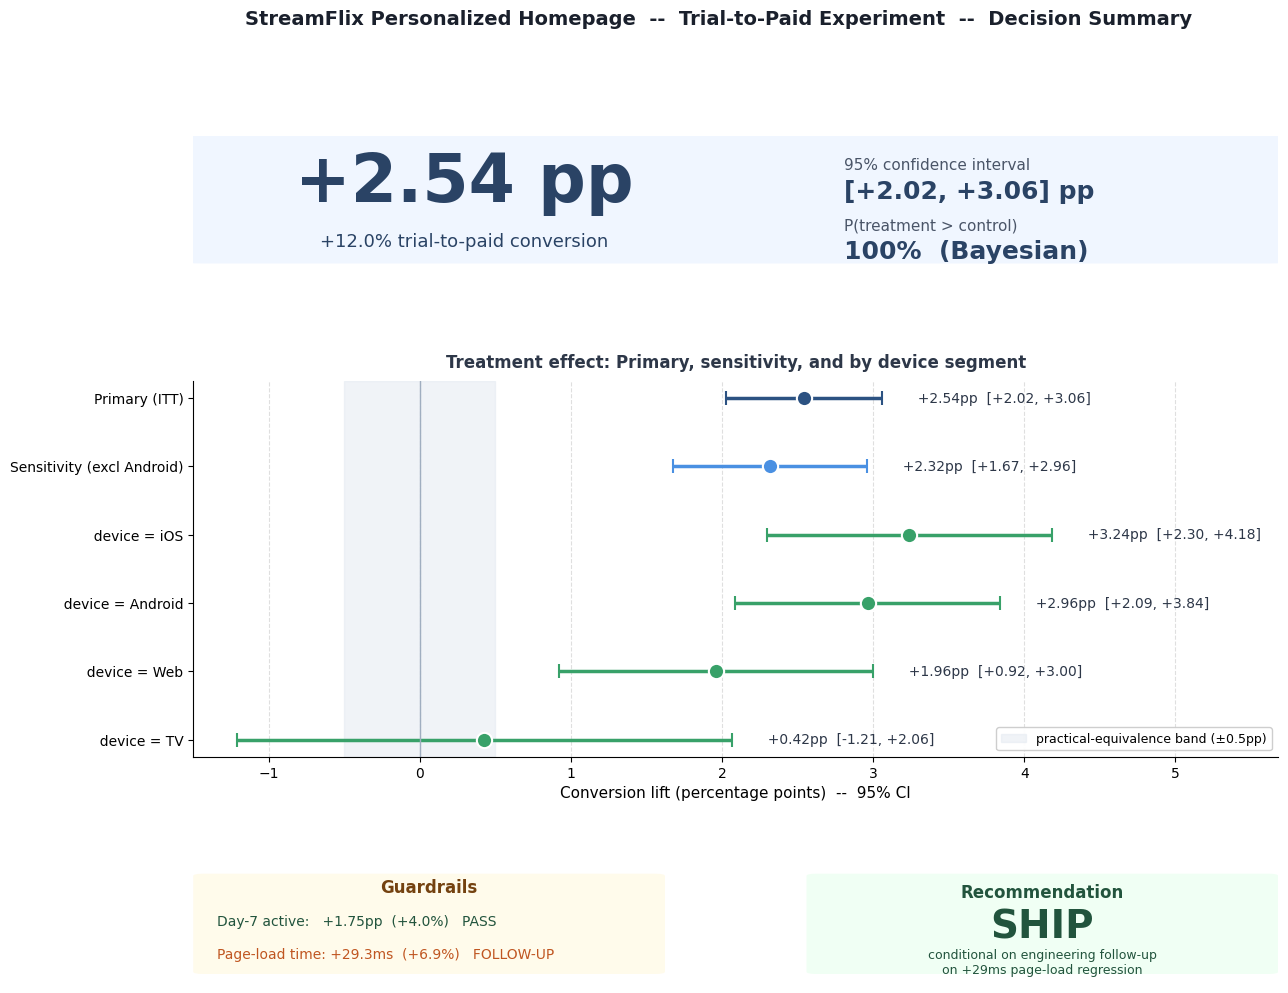

In [5]:
fig = plt.figure(figsize=(14, 11))
gs = fig.add_gridspec(
    3, 2,
    height_ratios=[0.7, 2.0, 0.6],
    width_ratios=[1, 1],
    hspace=0.55, wspace=0.30,
)

# ----- TOP HEADLINE PANEL -----
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis("off")
ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)

# Background card
ax_kpi.add_patch(FancyBboxPatch(
    (0.01, 0.05), 0.98, 0.95,
    boxstyle="round,pad=0.02", linewidth=0,
    facecolor="#F0F6FF", edgecolor="none",
))

# Big KPI numbers
ax_kpi.text(
    0.25, 0.65,
    f"+{primary.effect_absolute*100:.2f} pp",
    ha="center", va="center",
    fontsize=48, fontweight="bold", color="#2A4365",
)
ax_kpi.text(
    0.25, 0.20,
    f"+{primary.effect_relative*100:.1f}% trial-to-paid conversion",
    ha="center", va="center", fontsize=13, color="#2A4365",
)

# CI block
ax_kpi.text(
    0.60, 0.78,
    "95% confidence interval",
    ha="left", va="center", fontsize=11, color="#4A5568",
)
ax_kpi.text(
    0.60, 0.58,
    f"[+{primary.ci_lower*100:.2f}, +{primary.ci_upper*100:.2f}] pp",
    ha="left", va="center", fontsize=18, fontweight="bold", color="#2A4365",
)
ax_kpi.text(
    0.60, 0.32,
    "P(treatment > control)",
    ha="left", va="center", fontsize=11, color="#4A5568",
)
ax_kpi.text(
    0.60, 0.12,
    "100%  (Bayesian)",
    ha="left", va="center", fontsize=18, fontweight="bold", color="#2A4365",
)

# ----- MIDDLE: Forest plot of all key results -----
ax_forest = fig.add_subplot(gs[1, :])

# Compose rows: primary + sensitivity + device segments
forest_rows = [
    ("Primary (ITT)",           primary.effect_absolute*100, primary.ci_lower*100, primary.ci_upper*100, "#2C5282"),
    ("Sensitivity (excl Android)", sensitivity.effect_absolute*100, sensitivity.ci_lower*100, sensitivity.ci_upper*100, "#4A90E2"),
]
device_colors = {"iOS": "#38A169", "Android": "#38A169",
                 "Web": "#38A169", "TV": "#38A169"}
for _, r in device_seg.iterrows():
    forest_rows.append((
        f"  device = {r['segment']}",
        r["effect_abs"]*100, r["ci_lower"]*100, r["ci_upper"]*100,
        device_colors[r["segment"]],
    ))

labels  = [r[0] for r in forest_rows]
effects = [r[1] for r in forest_rows]
los     = [r[2] for r in forest_rows]
his     = [r[3] for r in forest_rows]
colors  = [r[4] for r in forest_rows]

y_pos = np.arange(len(forest_rows))[::-1]
for i, (label, e, lo, hi, c) in enumerate(forest_rows):
    yi = y_pos[i]
    ax_forest.errorbar(
        e, yi, xerr=[[e - lo], [hi - e]],
        fmt="o", color=c, markersize=11,
        ecolor=c, elinewidth=2.5, capsize=5,
        markeredgecolor="white", markeredgewidth=1.5,
    )
    ax_forest.text(
        hi + 0.18, yi,
        f"  {e:+.2f}pp  [{lo:+.2f}, {hi:+.2f}]",
        va="center", fontsize=10, color="#2D3748",
    )

ax_forest.axvline(0, color="#A0AEC0", linewidth=1)
ax_forest.axvspan(-0.5, 0.5, color="#E2E8F0", alpha=0.5,
                  label="practical-equivalence band (±0.5pp)")
ax_forest.set_yticks(y_pos)
ax_forest.set_yticklabels(labels, fontsize=10)
ax_forest.set_xlabel("Conversion lift (percentage points)  --  95% CI", fontsize=11)
ax_forest.set_title(
    "Treatment effect: Primary, sensitivity, and by device segment",
    fontsize=12, fontweight="bold", color="#2D3748", pad=10,
)
ax_forest.set_xlim(-1.5, max(his) + 1.5)
ax_forest.grid(axis="x", linestyle="--", alpha=0.4)
ax_forest.legend(loc="lower right", fontsize=9, framealpha=0.95)
for spine in ["top", "right"]:
    ax_forest.spines[spine].set_visible(False)


# ----- BOTTOM-LEFT: Guardrails snapshot -----
ax_guard = fig.add_subplot(gs[2, 0])
ax_guard.axis("off")
ax_guard.set_xlim(0, 1); ax_guard.set_ylim(0, 1)
ax_guard.add_patch(FancyBboxPatch(
    (0.02, 0.10), 0.96, 0.85,
    boxstyle="round,pad=0.02", linewidth=0,
    facecolor="#FFFBEB", edgecolor="none",
))
ax_guard.text(0.5, 0.85, "Guardrails", ha="center", va="center",
              fontsize=12, fontweight="bold", color="#744210")
ax_guard.text(
    0.05, 0.55,
    f"Day-7 active:   +{guard_d7.effect_absolute*100:.2f}pp  (+{guard_d7.effect_relative*100:.1f}%)   PASS",
    ha="left", va="center", fontsize=10, color="#22543D",
)
ax_guard.text(
    0.05, 0.25,
    f"Page-load time: +{guard_load.effect_absolute:.1f}ms  "
    f"(+{guard_load.effect_relative*100:.1f}%)   FOLLOW-UP",
    ha="left", va="center", fontsize=10, color="#C05621",
)


# ----- BOTTOM-RIGHT: Recommendation banner -----
ax_rec = fig.add_subplot(gs[2, 1])
ax_rec.axis("off")
ax_rec.set_xlim(0, 1); ax_rec.set_ylim(0, 1)
ax_rec.add_patch(FancyBboxPatch(
    (0.02, 0.10), 0.96, 0.85,
    boxstyle="round,pad=0.02", linewidth=0,
    facecolor="#F0FFF4", edgecolor="none",
))
ax_rec.text(0.5, 0.80, "Recommendation", ha="center", va="center",
            fontsize=12, fontweight="bold", color="#22543D")
ax_rec.text(0.5, 0.50, "SHIP", ha="center", va="center",
            fontsize=28, fontweight="bold", color="#22543D")
ax_rec.text(
    0.5, 0.18,
    "conditional on engineering follow-up\non +29ms page-load regression",
    ha="center", va="center", fontsize=9, color="#22543D",
)


# ----- Title & save -----
fig.suptitle(
    "StreamFlix Personalized Homepage  --  Trial-to-Paid Experiment  --  Decision Summary",
    fontsize=14, fontweight="bold", color="#1A202C", y=0.995,
)
plt.savefig(FIG_DIR / "06_hero_summary.png", dpi=150, bbox_inches="tight",
            facecolor="white")
print(f"📊 Saved hero figure -> {FIG_DIR}/06_hero_summary.png")